--- Starting Lagrangian Relaxation for Capacitated p-median ---
Iter. |     Lower Bound     |     Upper Bound     |  Gap (%)
---------------------------------------------------------------
   10 |           53218.223 |          103819.541 |    48.740
   20 |           63095.822 |           83545.641 |    24.477
   30 |           65932.652 |           83545.641 |    21.082
   40 |           67737.285 |           83545.641 |    18.922
   50 |           69361.144 |           83545.641 |    16.978
---------------------------------------------------------------
Solving exact CPMP for comparison...
Final LB: 69361.144 | Exact: 77837.716 | Duality Gap: 8476.572 (10.890%)


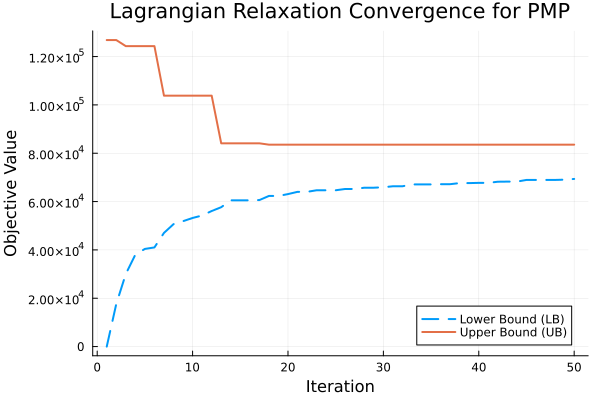

In [2]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 7 – Lagrangian relaxation
#  Section: Exercise 2.3
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP            # For mathematical programming
using HiGHS           # HiGHS solver
using LinearAlgebra   # For norm calculations
using CSV             # For reading CSV files
using DataFrames      # For handling DataFrame operations
using Distances       # Distance computations
using Printf          # For formatted output
using Plots           # For plotting

# Function to plot convergence of LB and UB
function plot_convergence(lb_history, ub_history)
    p = plot(1:length(lb_history), [lb_history ub_history],
        label=["Lower Bound (LB)" "Upper Bound (UB)"],
        xlabel="Iteration",
        ylabel="Objective Value",
        title="Lagrangian Relaxation Convergence for PMP",
        linewidth=2,
        linestyle=[:dash :solid],
        legend=:bottomright)
    display(p)
end

# Function to load data and compute distance matrix
function load_data(file_path)
    data = CSV.read(file_path, header=true, DataFrame)
    coordinates = Matrix{Float64}(data[:, 1:2])
    distance_matrix = Distances.pairwise(Distances.Haversine(), coordinates, dims=1)
    return data[:,"Demand"], distance_matrix
end

# Function to solve the p-median problem exactly
function solve_cpmedian_exact(demands, distance_matrix; p = 3, capacity = 60000)
    n = size(distance_matrix, 1)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[1:n, 1:n], Bin)  
    # Objective: Minimize total distance
    @objective(model, Min, sum(distance_matrix[i,j] * x[i,j] for i in 1:n, j in 1:n))
    # Constraint: Each customer assigned to one facility
    @constraint(model, [i=1:n], sum(x[i,j] for j in 1:n) == 1)
    # Constraint: Assignment only to open facilities
    @constraint(model, [i=1:n, j=1:n], x[i,j] <= x[j,j])
    # Constraint: Exactly p facilities opened
    @constraint(model, sum(x[j,j] for j in 1:n) == p)
    # Constraint: Capacity limit for each facility
    @constraint(model, [j in 1:n], sum(demands[i] * x[i, j] for i in 1:n) <= capacity * x[j,j])
    # Run the solver 
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model)
    else
        error("Optimal solution not found.")
    end
end

# Function to solve subproblem for a given facility j in the relaxed problem 
function solve_subproblem_j(modified_costs, demands, capacity)
    n = size(modified_costs, 1)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, y[1:n], Bin)  
    # Objective: Minimize total modified cost for facility j
    @objective(model, Min, sum(modified_costs[i] * y[i] for i in 1:n))
    # Constraint: Total demand assigned to facility j cannot exceed capacity
    @constraint(model, sum(demands[i] * y[i] for i in 1:n) <= capacity)
    # Run the solver
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model), [JuMP.value(y[i])>0.5 ? 1 : 0 for i in 1:n]
    end
end

# Function to solve subproblem for a given a set of facilities from the relaxed problem
function solve_cpmedian_exact_subset(selected_facilities, distance_matrix, demands, capacity)
    n = size(distance_matrix, 1)
    m = length(selected_facilities)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[1:n, 1:m], Bin)  
    # Objective: Minimize total distance
    @objective(model, Min, sum(distance_matrix[i, selected_facilities[j]] * x[i,j] for i in 1:n, j in 1:m))
    # Constraint: Each customer assigned to one facility
    @constraint(model, [i=1:n], sum(x[i,j] for j in 1:m) == 1)
    # Constraint: Capacity limit for each facility
    @constraint(model, [j in 1:m], sum(demands[i] * x[i, j] for i in 1:n) <= capacity)
    # Run the solver 
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model), [JuMP.value(x[i,j])>0.5 ? selected_facilities[j] : 0 for i in 1:n, j in 1:m]
    else
        error("Optimal solution for subset not found.")
    end
end

# Main Lagrangian Relaxation function
function solve_cpmedian_lagrangian(file_path; p = 3, capacity = 3516, iterations = 50, gap_tolerance = 1e-6)

    # Load problem data
    demands, distance_matrix = load_data(file_path)

    # Algorithm Initialization
    n = size(distance_matrix, 1) # Number of clients / facilities
    λ = zeros(n)                 # Lagrange multipliers
    θ = 0.15                     # A factor to update multiplier (Held-Karp)
    LB = -Inf                    # Best lower bound found so far
    UB = Inf                     # Best upper bound found so far
    LB_history = []              # Store lower bound history
    UB_history = []              # Store upper bound history
    best_feasible = nothing      # Store best feasible solution found

    # Counter logic for robust convergence: reduce θ after 3 iterations without improvement in LB
    no_improve_limit = 3
    no_improve_counter = 0

    println("--- Starting Lagrangian Relaxation for Capacitated p-median ---")
    println("Iter. |     Lower Bound     |     Upper Bound     |  Gap (%)")
    println("-"^63)

    # Main iterative loop
    for iteration in 1:iterations
        # ---- 1. Solve the relaxed problem to get a lower bound ---
        
        # 1a. Modify costs with current λ
        modified_costs = distance_matrix .- λ

        # 1b. Solve subproblems for each facility
        facility_costs = zeros(n)
        facility_assignments = zeros(Int, n, n)
        for facility_id in 1:n
            facility_costs[facility_id], 
            facility_assignments[facility_id,:] = solve_subproblem_j(modified_costs[:, facility_id], 
                                                                     demands, 
                                                                     capacity)
        end

        # 1c. Select p facilities with lowest modified cost
        chosen_facilities = sortperm(facility_costs)[1:p]

        # 1d. Calculate the relaxed solution
        x_relaxed = vec(sum(facility_assignments[chosen_facilities, :], dims=1))

        # 1e. Calculate Lagrangian Lower Bound
        current_LB = sum(λ) + sum(facility_costs[chosen_facilities])

        # 1f. Update LB and step size factor
        if current_LB > LB
            LB = current_LB
            no_improve_counter = 0
        else
            no_improve_counter += 1
            if no_improve_counter >= no_improve_limit
                θ *= 0.95
                no_improve_counter = 0
            end
        end

        # 1g. Store LB history
        push!(LB_history, LB)

        # ---- 2. Heuristic to find a feasible solution and get an upper bound ---

        # 2a. Repair heuristic based on Lagrangian regret
        current_UB, best_feasible = solve_cpmedian_exact_subset(chosen_facilities, distance_matrix, demands, capacity)
        
        # 2b. Update UB
        UB = min(UB, current_UB)

        # 2c. Store UB history
        push!(UB_history, UB)

        # ---- 3. Subgradient update ---
        
        # 3. Calculate subgradient
        g = ones(n) - x_relaxed

        # 3a. Calculate step size
        α = θ * (UB - LB) / (norm(g)^2 + 1e-10)

        # 3b. Update Lagrange multipliers
        λ .+= α .* g
        λ .= max.(0.0, λ) # Ensure non-negativity

        if iteration % 10 == 0
            @printf("%5d | %19.3f | %19.3f | %9.3f\n", iteration, LB, UB, ((UB - LB) / UB) * 100)
        end

        # 3c. Check for convergence
        gap = isfinite(UB) ? (UB - LB) / UB : Inf
        if isfinite(gap) && gap <= gap_tolerance
            println("Converged: gap <= tolerance.")
            break
        end
    end

    # Final summary and Exact solve for comparison
    exact_objective = solve_cpmedian_exact(demands, distance_matrix, p=p, capacity=capacity)
    println("-"^63)
    println("Solving exact CPMP for comparison...")
    @printf("Final LB: %8.3f | Exact: %8.3f | Duality Gap: %8.3f (%5.3f%%)\n", LB, exact_objective, (exact_objective - LB), ((exact_objective - LB) / exact_objective) * 100)

    # Plot convergence
    plot_convergence(LB_history, UB_history)
end

# Example usage
solve_cpmedian_lagrangian("data/exercise_cpmp.csv", p = 3, capacity = 3516, iterations = 50, gap_tolerance = 1e-6)